In [ ]:
pip install opencv-python-headless matplotlib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL
from PIL import Image
import io
import os # Import the os module

def take_photo(filename='/content/drive/My Drive/Estudiantes/photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            try {
                const div = document.createElement('div');
                const capture = document.createElement('button');
                capture.textContent = 'Tomar Foto';
                div.appendChild(capture);

                const video = document.createElement('video');
                video.style.display = 'block';
                // Request camera access with permissions
                const stream = await navigator.mediaDevices.getUserMedia({video: true});

                document.body.appendChild(div);
                div.appendChild(video);
                video.srcObject = stream;
                await video.play();

                // Espera a que el botón sea clickeado.
                await new Promise((resolve) => capture.onclick = resolve);

                const canvas = document.createElement('canvas');
                canvas.width = video.videoWidth;
                canvas.height = video.videoHeight;
                canvas.getContext('2d').drawImage(video, 0, 0);
                stream.getVideoTracks()[0].stop();
                div.remove();
                return canvas.toDataURL('image/jpeg', quality);
            } catch (error) {
                // Handle errors, especially permission denied
                console.error('Error accessing camera:', error);
                // You might want to display an error message to the user here
                alert('Permission denied to access camera. Please grant permission.');
                return null; // Or throw an error to stop execution
            }
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))

    # Check if data is null (indicating an error)
    if data is None:
        return None # Or handle the error as needed

    binary = b64decode(data.split(',')[1])

    # Ensure the directory exists
    # Get the current working directory
    current_directory = os.getcwd()
    # Combine the current directory and the 'Estudiantes' folder
    save_directory = os.path.join(current_directory, 'Estudiantes')
    # Create the directory if it doesn't exist
    os.makedirs(save_directory, exist_ok=True)
    # Combine the directory and filename for saving
    file_path = os.path.join(save_directory, filename)
    # Guardar la imagen en el archivo
    with open(file_path, 'wb') as f: # Changed filename to file_path
        f.write(binary)

    # Retornar un objeto PIL.Image
     #return Image.open(io.BytesIO(binary)).resize((64, 64), PIL.Image.Resampling.LANCZOS)


# Usar la función y mostrar la imagen
img_pil = take_photo()  # Llama a la función

# Check if img_pil is None before displaying
if img_pil is not None:
    display(img_pil)  # Muestra la imagen resultante
else:
    print("Failed to capture photo.")

<IPython.core.display.Javascript object>

Failed to capture photo.


<IPython.core.display.Javascript object>

Photo saved as photo_20250131_122531.jpg in /content/drive/My Drive/Estudiantes/


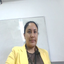

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL
from PIL import Image
import io
import os
from datetime import datetime

def take_photo(base_path='/content/drive/My Drive/Estudiantes/', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            try {
                const div = document.createElement('div');
                const capture = document.createElement('button');
                capture.textContent = 'Tomar Foto';
                div.appendChild(capture);

                const video = document.createElement('video');
                video.style.display = 'block';
                const stream = await navigator.mediaDevices.getUserMedia({video: true});

                document.body.appendChild(div);
                div.appendChild(video);
                video.srcObject = stream;
                await video.play();

                // Espera a que el botón sea clickeado.
                await new Promise((resolve) => capture.onclick = resolve);

                const canvas = document.createElement('canvas');
                canvas.width = video.videoWidth;
                canvas.height = video.videoHeight;
                canvas.getContext('2d').drawImage(video, 0, 0);
                stream.getVideoTracks()[0].stop();
                div.remove();
                return canvas.toDataURL('image/jpeg', quality);
            } catch (error) {
                console.error('Error accessing camera:', error);
                alert('Permission denied to access camera. Please grant permission.');
                return null;
            }
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))

    if data is None:
        print("Failed to capture photo.")
        return None

    binary = b64decode(data.split(',')[1])

    # Ensure the directory exists
    os.makedirs(base_path, exist_ok=True)

    # Create a unique filename with timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f'photo_{timestamp}.jpg'
    file_path = os.path.join(base_path, filename)

    # Save the image to the file
    with open(file_path, 'wb') as f:
        f.write(binary)

    print(f'Photo saved as {filename} in {base_path}')

    # Return a PIL.Image object
    return Image.open(io.BytesIO(binary)).resize((64, 64), PIL.Image.Resampling.LANCZOS)

# Use the function and display the image
img_pil = take_photo()
if img_pil is not None:
    display(img_pil)


<IPython.core.display.Javascript object>

Photo saved as photo_person_0_0.jpg in /content/drive/My Drive/Estudiantes/


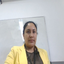

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL
from PIL import Image
import io
import os

# Inicializa el contador global
photo_counter = 0

def take_photo(base_path='/content/drive/My Drive/Estudiantes/', quality=0.8):
    global photo_counter

    js = Javascript('''
        async function takePhoto(quality) {
            try {
                const div = document.createElement('div');
                const capture = document.createElement('button');
                capture.textContent = 'Tomar Foto';
                div.appendChild(capture);

                const video = document.createElement('video');
                video.style.display = 'block';
                const stream = await navigator.mediaDevices.getUserMedia({video: true});

                document.body.appendChild(div);
                div.appendChild(video);
                video.srcObject = stream;
                await video.play();

                // Espera a que el botón sea clickeado.
                await new Promise((resolve) => capture.onclick = resolve);

                const canvas = document.createElement('canvas');
                canvas.width = video.videoWidth;
                canvas.height = video.videoHeight;
                canvas.getContext('2d').drawImage(video, 0, 0);
                stream.getVideoTracks()[0].stop();
                div.remove();
                return canvas.toDataURL('image/jpeg', quality);
            } catch (error) {
                console.error('Error accessing camera:', error);
                alert('Permission denied to access camera. Please grant permission.');
                return null;
            }
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))

    if data is None:
        print("Failed to capture photo.")
        return None

    binary = b64decode(data.split(',')[1])

    # Ensure the directory exists
    os.makedirs(base_path, exist_ok=True)

    # Create a filename using the counter
    filename = f'photo_person_{photo_counter // 6}_{photo_counter % 6}.jpg'
    file_path = os.path.join(base_path, filename)

    # Save the image to the file
    with open(file_path, 'wb') as f:
        f.write(binary)

    print(f'Photo saved as {filename} in {base_path}')

    # Increment the counter and reset if it reaches 6
    photo_counter += 1
    if photo_counter % 6 == 0:
        photo_counter = 0

    # Return a PIL.Image object
    return Image.open(io.BytesIO(binary)).resize((64, 64), PIL.Image.Resampling.LANCZOS)

# Use the function and display the image
img_pil = take_photo()
if img_pil is not None:
    display(img_pil)


<IPython.core.display.Javascript object>

Photo saved as photo_person_0_0.jpg in /content/drive/My Drive/Estudiantes/


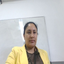

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL
from PIL import Image
import io
import os

# Inicializa el contador global
photo_counter = 0
person_counter = 0  # Contador adicional para identificar a la persona

def take_photo(base_path='/content/drive/My Drive/Estudiantes/', quality=0.8):
    global photo_counter, person_counter

    js = Javascript('''
        async function takePhoto(quality) {
            try {
                const div = document.createElement('div');
                const capture = document.createElement('button');
                capture.textContent = 'Tomar Foto';
                div.appendChild(capture);

                const video = document.createElement('video');
                video.style.display = 'block';
                const stream = await navigator.mediaDevices.getUserMedia({video: true});

                document.body.appendChild(div);
                div.appendChild(video);
                video.srcObject = stream;
                await video.play();

                // Espera a que el botón sea clickeado.
                await new Promise((resolve) => capture.onclick = resolve);

                const canvas = document.createElement('canvas');
                canvas.width = video.videoWidth;
                canvas.height = video.videoHeight;
                canvas.getContext('2d').drawImage(video, 0, 0);
                stream.getVideoTracks()[0].stop();
                div.remove();
                return canvas.toDataURL('image/jpeg', quality);
            } catch (error) {
                console.error('Error accessing camera:', error);
                alert('Permission denied to access camera. Please grant permission.');
                return null;
            }
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))

    if data is None:
        print("Failed to capture photo.")
        return None

    binary = b64decode(data.split(',')[1])

    # Ensure the directory exists
    os.makedirs(base_path, exist_ok=True)

    # Create a filename using the counter
    filename = f'photo_person_{person_counter}_{photo_counter}.jpg'
    file_path = os.path.join(base_path, filename)

    # Save the image to the file
    with open(file_path, 'wb') as f:
        f.write(binary)

    print(f'Photo saved as {filename} in {base_path}')

    # Increment the counter and manage person_counter
    photo_counter += 1
    if photo_counter == 6:
        photo_counter = 0
        person_counter += 1  # Incrementa el contador de persona después de 6 fotos

    # Return a PIL.Image object
    return Image.open(io.BytesIO(binary)).resize((64, 64), PIL.Image.Resampling.LANCZOS)

# Use the function and display the image
img_pil = take_photo()
if img_pil is not None:
    display(img_pil)


<IPython.core.display.Javascript object>

Photo saved as photo_person_0_0.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_person_0_1.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_person_0_2.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_person_0_3.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_person_0_4.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_person_0_5.jpg in /content/drive/My Drive/Estudiantes/


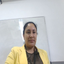

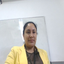

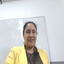

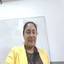

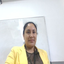

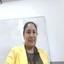

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL
from PIL import Image
import io
import os

# Inicializa el contador global
photo_counter = 0
person_counter = 0

def take_photos(base_path='/content/drive/My Drive/Estudiantes/', quality=0.8):
    global photo_counter, person_counter

    js = Javascript('''
        async function takePhotos(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Tomar Foto';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            let dataURLs = [];
            for (let i = 0; i < 6; i++) {
                // Espera a que el botón sea clickeado.
                await new Promise((resolve) => capture.onclick = resolve);
                canvas.getContext('2d').drawImage(video, 0, 0);
                dataURLs.push(canvas.toDataURL('image/jpeg', quality));
            }
            stream.getVideoTracks()[0].stop();
            div.remove();
            return dataURLs;
        }
    ''')
    display(js)
    data_urls = eval_js('takePhotos({})'.format(quality))

    images = []
    for data_url in data_urls:
        if data_url is None:
            print("Failed to capture photo.")
            continue

        binary = b64decode(data_url.split(',')[1])

        # Ensure the directory exists
        os.makedirs(base_path, exist_ok=True)

        # Create a filename using the counter
        filename = f'photo_person_{person_counter}_{photo_counter}.jpg'
        file_path = os.path.join(base_path, filename)

        # Save the image to the file
        with open(file_path, 'wb') as f:
            f.write(binary)

        print(f'Photo saved as {filename} in {base_path}')
        photo_counter += 1

        # Incrementa el contador de persona después de 6 fotos
        if photo_counter == 6:
            photo_counter = 0
            person_counter += 1

        # Add to images list
        images.append(Image.open(io.BytesIO(binary)).resize((64, 64), PIL.Image.Resampling.LANCZOS))

    return images

# Use the function and display the images
photos = take_photos()
for img_pil in photos:
    display(img_pil)


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL
from PIL import Image
import io
import os

# Inicializa el contador global
photo_counter = 0
person_counter = 0

def set_person_counter(new_counter):
    global person_counter
    person_counter = new_counter
    print(f"Person counter set to {person_counter}")

def take_photos(base_path='/content/drive/My Drive/Estudiantes/', quality=0.8):
    global photo_counter, person_counter

    js = Javascript('''
        async function takePhotos(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Tomar Foto';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            let dataURLs = [];
            for (let i = 0; i < 6; i++) {
                await new Promise((resolve) => capture.onclick = resolve);
                canvas.getContext('2d').drawImage(video, 0, 0);
                dataURLs.push(canvas.toDataURL('image/jpeg', quality));
            }
            stream.getVideoTracks()[0].stop();
            div.remove();
            return dataURLs;
        }
    ''')
    display(js)
    data_urls = eval_js('takePhotos({})'.format(quality))

    images = []
    for data_url in data_urls:
        if data_url is None:
            print("Failed to capture photo.")
            continue

        binary = b64decode(data_url.split(',')[1])

        os.makedirs(base_path, exist_ok=True)
        filename = f'photo_person_{person_counter}_{photo_counter}.jpg'
        file_path = os.path.join(base_path, filename)
        with open(file_path, 'wb') as f:
            f.write(binary)

        print(f'Photo saved as {filename} in {base_path}')
        photo_counter += 1

        if photo_counter == 6:
            photo_counter = 0
            person_counter += 1

        images.append(Image.open(io.BytesIO(binary)).resize((64, 64), PIL.Image.Resampling.LANCZOS))

    return images

def update_person_counter():
    from IPython.display import HTML, clear_output
    html_code = """
    <input type="text" id="person_counter" placeholder="Enter new person counter">
    <button onclick="google.colab.kernel.invokeFunction('notebook.set_person_counter', [parseInt(document.getElementById('person_counter').value)], {});">Update Counter</button>
    """
    display(HTML(html_code))

update_person_counter()  # Show the update interface


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL
from PIL import Image
import io
import os

# Inicializa el contador global y el nombre del usuario
photo_counter = 0
user_name = "default_user"

def take_photos(base_path='/content/drive/My Drive/Estudiantes/', quality=0.8):
    global photo_counter, user_name

    js = Javascript('''
        async function takePhotos(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Tomar Foto';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            let dataURLs = [];
            for (let i = 0; i < 6; i++) {
                await new Promise((resolve) => capture.onclick = resolve);
                canvas.getContext('2d').drawImage(video, 0, 0);
                dataURLs.push(canvas.toDataURL('image/jpeg', quality));
            }
            stream.getVideoTracks()[0].stop();
            div.remove();
            return dataURLs;
        }
    ''')
    display(js)
    data_urls = eval_js('takePhotos({})'.format(quality))

    images = []
    for data_url in data_urls:
        if data_url is None:
            print("Failed to capture photo.")
            continue

        binary = b64decode(data_url.split(',')[1])

        os.makedirs(base_path, exist_ok=True)
        filename = f'photo_{user_name}_{photo_counter}.jpg'
        file_path = os.path.join(base_path, filename)
        with open(file_path, 'wb') as f:
            f.write(binary)

        print(f'Photo saved as {filename} in {base_path}')
        photo_counter += 1

        if photo_counter == 6:
            photo_counter = 0

        images.append(Image.open(io.BytesIO(binary)).resize((64, 64), PIL.Image.Resampling.LANCZOS))

    return images

def update_user_name():
    from IPython.display import HTML, clear_output
    html_code = """
    <input type="text" id="user_name" placeholder="Enter user name">
    <button onclick="google.colab.kernel.invokeFunction('notebook.set_user_name', [document.getElementById('user_name').value], {});">Set User Name</button>
    """
    display(HTML(html_code))

def set_user_name(name):
    global user_name
    user_name = name
    print(f"User name set to {user_name}")

# Register the function to be callable from JavaScript
from google.colab import output
output.register_callback('notebook.set_user_name', set_user_name)

update_user_name()  # Show the user name update interface


User name set to Allll


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL
from PIL import Image
import io
import os

# Inicializa el contador global y el nombre del usuario
photo_counter = 0
user_name = "default_user"

def take_photos(base_path='/content/drive/My Drive/Estudiantes/', quality=0.8):
    global photo_counter, user_name

    js = Javascript('''
        async function takePhotos(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Tomar Foto';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            let dataURLs = [];
            for (let i = 0; i < 6; i++) {
                await new Promise((resolve) => capture.onclick = resolve);
                canvas.getContext('2d').drawImage(video, 0, 0);
                dataURLs.push(canvas.toDataURL('image/jpeg', quality));
            }
            stream.getVideoTracks()[0].stop();
            div.remove();
            return dataURLs;
        }
    ''')
    display(js)
    data_urls = eval_js('takePhotos({})'.format(quality))

    images = []
    for data_url in data_urls:
        if data_url is None:
            print("Failed to capture photo.")
            continue

        binary = b64decode(data_url.split(',')[1])

        os.makedirs(base_path, exist_ok=True)
        filename = f'photo_{user_name}_{photo_counter}.jpg'
        file_path = os.path.join(base_path, filename)
        with open(file_path, 'wb') as f:
            f.write(binary)

        print(f'Photo saved as {filename} in {base_path}')
        photo_counter += 1

        if photo_counter == 6:
            photo_counter = 0

        images.append(Image.open(io.BytesIO(binary)).resize((64, 64), PIL.Image.Resampling.LANCZOS))

    return images

def update_user_name():
    from IPython.display import HTML, clear_output
    html_code = """
    <input type="text" id="user_name" placeholder="Enter user name">
    <button onclick="google.colab.kernel.invokeFunction('notebook.set_user_name_and_take_photos', [document.getElementById('user_name').value], {});">Set User Name and Take Photos</button>
    """
    display(HTML(html_code))

def set_user_name_and_take_photos(name):
    global user_name
    user_name = name
    print(f"User name set to {user_name}")
    return take_photos()  # Call take_photos function after setting the user name

# Register the function to be callable from JavaScript
from google.colab import output
output.register_callback('notebook.set_user_name_and_take_photos', set_user_name_and_take_photos)

update_user_name()  # Show the user name update interface


User name set to GeraldChavez2


<IPython.core.display.Javascript object>

Photo saved as photo_GeraldChavez2_0.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_GeraldChavez2_1.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_GeraldChavez2_2.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_GeraldChavez2_3.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_GeraldChavez2_4.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_GeraldChavez2_5.jpg in /content/drive/My Drive/Estudiantes/
User name set to Julian Coloma


<IPython.core.display.Javascript object>

Photo saved as photo_Julian Coloma_0.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_Julian Coloma_1.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_Julian Coloma_2.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_Julian Coloma_3.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_Julian Coloma_4.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_Julian Coloma_5.jpg in /content/drive/My Drive/Estudiantes/
User name set to Julian Coloma2


<IPython.core.display.Javascript object>

Photo saved as photo_Julian Coloma2_0.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_Julian Coloma2_1.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_Julian Coloma2_2.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_Julian Coloma2_3.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_Julian Coloma2_4.jpg in /content/drive/My Drive/Estudiantes/
Photo saved as photo_Julian Coloma2_5.jpg in /content/drive/My Drive/Estudiantes/
